# Music Recommendation System — 01 Exploratory Data Analysis

A **collaborative-filtering** recommender on the Last.fm (hetrec2011) dataset. The signal is **implicit**: how many times each user played each artist — there are *no explicit ratings*. We recommend new artists from listening patterns alone.

Because feedback is implicit, there is no rating to predict, so notebook 03 evaluates with **ranking metrics only** (Precision@k / Recall@k).

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import utils
plays=utils.load_interactions(); names=utils.load_items()
print('interactions:',plays.shape,'| users:',plays.user.nunique(),'| artists:',plays.item.nunique())
plays.head()

interactions: (92834, 3) | users: 1892 | artists: 17632


,user,item,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


## 1. Play-count distribution

Play counts span several orders of magnitude (a few super-fans dominate), so a log scale is needed — and is why we log-compress the matrix.

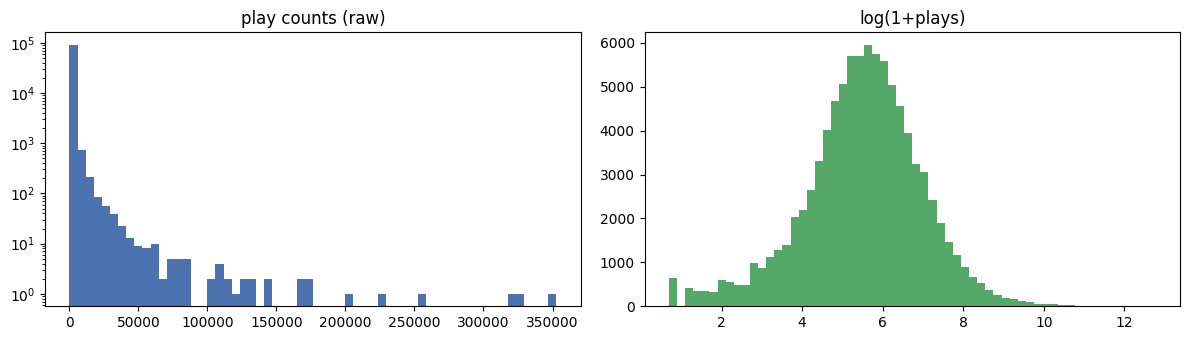

count     92834.0
mean        745.2
std        3751.3
min           1.0
25%         107.0
50%         260.0
75%         614.0
max      352698.0


In [2]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(plays['weight'],bins=60,color='#4c72b0'); ax[0].set_title('play counts (raw)'); ax[0].set_yscale('log')
ax[1].hist(np.log1p(plays['weight']),bins=60,color='#55a868'); ax[1].set_title('log(1+plays)')
plt.tight_layout(); plt.show()
print(plays['weight'].describe().round(1).to_string())

## 2. Activity per user / per artist

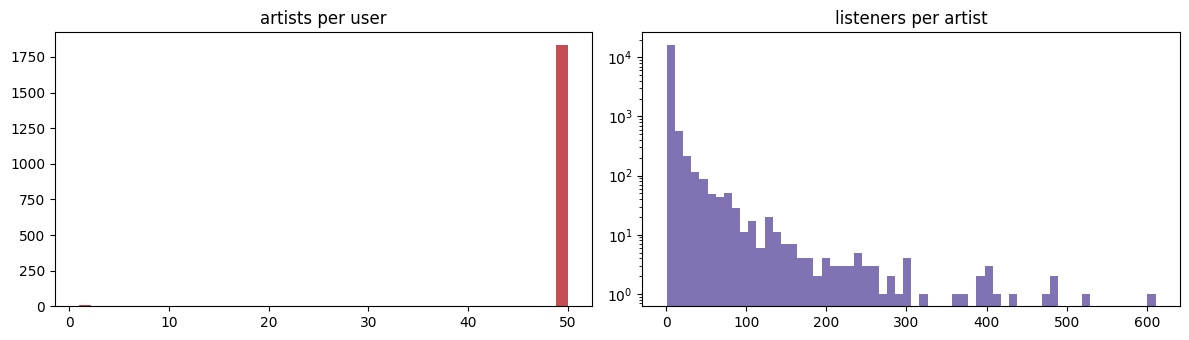

artists per user: median 50 max 50
listeners per artist: median 1 max 611


In [3]:
ppu=plays.groupby('user').size(); ppa=plays.groupby('item').size()
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(ppu,bins=40,color='#c44e52'); ax[0].set_title('artists per user')
ax[1].hist(ppa,bins=60,color='#8172b3'); ax[1].set_title('listeners per artist'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()
print('artists per user: median %d max %d'%(ppu.median(),ppu.max())); print('listeners per artist: median %d max %d'%(ppa.median(),ppa.max()))

## 3. Sparsity

In [4]:
nu,ni=plays.user.nunique(),plays.item.nunique(); d=len(plays)/(nu*ni)
print(f'{nu} users x {ni} artists = {nu*ni:,} cells; {len(plays):,} interactions')
print('density: %.3f%% (sparsity %.3f%%)'%(100*d,100*(1-d)))

1892 users x 17632 artists = 33,359,744 cells; 92,834 interactions
density: 0.278% (sparsity 99.722%)


## 4. Most-played artists (by total plays)

In [5]:
top=plays.groupby('item')['weight'].sum().sort_values(ascending=False).head(10)
top.index=top.index.map(names)
print(top.to_string())

item
Britney Spears        2393140
Depeche Mode          1301308
Lady Gaga             1291387
Christina Aguilera    1058405
Paramore               963449
Madonna                921198
Rihanna                905423
Shakira                688529
The Beatles            662116
Katy Perry             532545


## 5. Summary

- **1,892 users, 17,632 artists, 92,834 interactions** — the play matrix is **>99% sparse**.
- Play counts are extremely skewed (a handful of artists get millions of plays); log1p compression turns raw counts into a stable confidence weight.
- Each user listens to ~50 artists on average. Notebooks 02–03 restrict to the 2,000 most-played artists and compare item-CF vs matrix factorization on **ranking** quality.